# Previsão de Velocidade do Vento Utilizando Modelo Seq2Seq com Mecanismo de Atenção

Este notebook apresenta um modelo de aprendizado profundo para previsão da velocidade do vento com 6 horas de antecedência no Parque Eólico Delta do Maranhão.

## Objetivos Alcançados
- Desenvolvimento de um modelo preditivo com MAE de 0.16 m/s para previsão de velocidade do vento
- Capacidade de prever tendências e identificar anomalias com 6 horas de antecedência
- Monitoramento efetivo do sensor ws100 (velocidade do vento a 100m de altura)

## Arquitetura do Modelo Implementado
- **Modelo Base**: Sequence-to-Sequence (Seq2Seq) com mecanismo de Atenção
- **Encoder**: LSTM Bidirecional com 512 unidades totais
- **Decoder**: LSTM com 512 unidades e mecanismo de Atenção
- **Entrada**: Série temporal com 72 timesteps (histórico de 12 horas)
- **Saída**: Previsão de 36 timesteps (6 horas à frente)

## Parte do Trabalho de Conclusão de Curso
Este notebook representa a segunda etapa do trabalho, focada no desenvolvimento do modelo preditivo, complementando a Análise Exploratória de Dados (EDA) realizada anteriormente.

In [46]:
# %%
# Importacao das bibliotecas necessarias
# Manipulacao de dados
import os
import glob
import ctypes
import site
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pywt  # Biblioteca para transformacoes wavelet
import keras_tuner as kt

# Pre-processamento
from sklearn.preprocessing import MinMaxScaler

# Otimizar alocacao de memoria GPU - reduz fragmentacao
os.environ['TF_GPU_ALLOCATOR'] = 'cuda_malloc_async'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'  # Reduce TensorFlow logging verbosity

# Garante runtime de GPU no Arch Linux (cuSOLVER e libs CUDA via wheel)
def configure_tensorflow_gpu_runtime():
    """Configura paths CUDA do venv e pre-carrega bibliotecas antes do import do TensorFlow."""
    current_ld = os.environ.get('LD_LIBRARY_PATH', '')
    candidate_dirs = []

    for sp in site.getsitepackages():
        candidate_dirs.extend(glob.glob(os.path.join(sp, 'nvidia', '*', 'lib')))

    if 'VIRTUAL_ENV' in os.environ:
        candidate_dirs.extend(
            glob.glob(
                os.path.join(
                    os.environ['VIRTUAL_ENV'],
                    'lib',
                    'python*',
                    'site-packages',
                    'nvidia',
                    '*',
                    'lib',
                )
            )
        )

    valid_dirs = []
    for lib_dir in candidate_dirs:
        if os.path.isdir(lib_dir) and lib_dir not in valid_dirs:
            valid_dirs.append(lib_dir)

    if valid_dirs:
        merged = ':'.join(valid_dirs)
        os.environ['LD_LIBRARY_PATH'] = f"{merged}:{current_ld}" if current_ld else merged

        # Pre-carrega libs CUDA para evitar falha de resolucao dinamica no kernel do VS Code
        preload_libs = [
            'libcudart.so.12',
            'libcublas.so.12',
            'libcudnn.so.9',
            'libcusolver.so.11',
        ]
        for lib_name in preload_libs:
            for lib_dir in valid_dirs:
                lib_path = os.path.join(lib_dir, lib_name)
                if os.path.exists(lib_path):
                    try:
                        ctypes.CDLL(lib_path, mode=ctypes.RTLD_GLOBAL)
                    except OSError:
                        pass
                    break

    return valid_dirs

cuda_lib_dirs = configure_tensorflow_gpu_runtime()
print('CUDA lib dirs found:', len(cuda_lib_dirs))

# Componentes do modelo TCN
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input,
    Conv1D,
    BatchNormalization,
    Bidirectional,
    Activation,
    Dropout,
    Dense,
    Add,
    LayerNormalization,
    Flatten,
    Reshape,
    SpatialDropout1D,
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.regularizers import l2
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras import Sequential
from tcn import TCN

# Metricas de avaliacao
from sklearn.metrics import mean_absolute_error, mean_squared_error

import keras_tuner as kt

import tensorflow as tf
print('TensorFlow:', tf.__version__)
print('Python:', os.environ.get('VIRTUAL_ENV', 'sem VIRTUAL_ENV'))
print('GPUs:', tf.config.list_physical_devices('GPU'))

CUDA lib dirs found: 11
TensorFlow: 2.21.0
Python: /home/zino/projects/wind-speed-forescasting/.venv
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 1. Carregamento e Pré-processamento dos Dados

O processo de preparação dos dados inclui:
1. Carregamento dos dados de velocidade do vento previamente processados
2. Normalização usando MinMaxScaler para garantir convergência eficiente do modelo
3. Estruturação das sequências de entrada e saída no formato adequado para o modelo Seq2Seq
4. Divisão dos dados em conjuntos de treino (77%), validação (18%) e teste (5%)

In [ ]:
from xml.parsers.expat import model


variables = pd.read_csv('../data/dataset.csv', index_col=0, parse_dates=True)
print("Processed data loaded successfully.")

# Definição das funções de pré-processamento e engenharia de features

# Função de denoising com wavelet
# Esta função aplica técnicas de wavelet para redução de ruído em sinais
def wavelet_denoising(signal, wavelet='sym18', level=2):
    """
    Aplica técnica de denoising wavelet para reduzir o ruído do sinal
    
    Parâmetros:
    signal: array-like - O sinal de entrada a ser processado
    wavelet: str - O tipo de wavelet a ser utilizado (default: 'sym18')
    level: int - O nível de decomposição wavelet (default: 2)
    
    Retorna:
    array-like - Sinal reconstruído após a remoção de ruído
    """
    coeffs = pywt.wavedec(signal, wavelet, mode='periodization', level=level)

    sigma = np.median(np.abs(coeffs[-level])) / 0.6745
    uthresh = sigma * np.sqrt(2 * np.log(len(signal)))

    coeffs[1:] = [pywt.threshold(i, value=uthresh, mode='soft') for i in coeffs[1:]]

    reconstructed_signal = pywt.waverec(coeffs, wavelet, mode='periodization')
    return reconstructed_signal[:len(signal)]

# Lista das colunas que serão submetidas ao processo de denoising
columns_to_denoise = ['ws100', 'wdisp40', 'vertdisp40', 'wdir40', 'cis1', 'humid', 'temp']

# Aplica o denoising em cada coluna e armazena os resultados
for col in columns_to_denoise:
    if col in variables.columns:
        denoised_signal = wavelet_denoising(variables[col].values)
        variables[f'{col}_wavelet'] = denoised_signal
    else:
        raise ValueError(f"A coluna '{col}' não existe no conjunto de dados.")
print("Processed data loaded successfully.")

scaler_ws100 = MinMaxScaler()
scaler_other = MinMaxScaler()

variables_scaled = variables.copy()

ws100_columns = ['ws100_wavelet']
other_columns = variables.columns.drop('ws100_wavelet').tolist()

variables_scaled[ws100_columns] = scaler_ws100.fit_transform(variables[ws100_columns])
variables_scaled[other_columns] = scaler_other.fit_transform(variables[other_columns])

print(f"Shape of scaled data: {variables_scaled.shape}")

input_steps = 36  
output_steps = 36  

data_array = variables_scaled.values

target_col_index = variables_scaled.columns.get_loc('ws100_wavelet')

num_decoder_features = 1  
num_encoder_features = variables_scaled.shape[1]

def create_sequences(data, input_steps, output_steps, target_col_index):
    """
    Create input and output sequences for the Seq2Seq model using Teacher forcing.
    """
    X = []
    y = []
    
    for i in range(len(data) - input_steps - output_steps + 1):
        X.append(data[i:(i + input_steps)])
        
        y.append(data[i + input_steps:i + input_steps + output_steps, target_col_index].reshape(-1, 1))
    
    return np.array(X), np.array(y)

data_array = variables_scaled.values

target_col_index = variables_scaled.columns.get_loc('ws100_wavelet')

X, y = create_sequences(data_array, input_steps, output_steps, target_col_index)


print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

train_end = int(X.shape[0] * 0.77)
val_end = int(X.shape[0] * 0.95)

X_train = X[:train_end]
y_train = y[:train_end]

X_val = X[train_end:val_end]
y_val = y[train_end:val_end]

X_test = X[val_end:]
y_test = y[val_end:]

def build_seq2seq_attention_model(hp):
    """
    Builds a TCN model for multi-step forecasting.
    """

    dilation_count = hp.Int('dilation_count', min_value=1, max_value=5, step=1)
    dilations = [2 ** i for i in range(dilation_count)]
    filters = hp.Int('filters', min_value=32, max_value=256, step=32)
    kernel_size = hp.Int('kernel_size', min_value=2, max_value=5, step=1)
    nb_stacks = hp.Int('nb_stacks', min_value=1, max_value=3, step=1)
    dropout_rate = hp.Float('dropout_rate', min_value=0.1, max_value=0.5, step=0.1)
    learning_rate = hp.Float('learning_rate', min_value=1e-5, max_value=1e-2, sampling='LOG')

    optimizer = Adam(learning_rate=learning_rate)
    
    inputs = Input(shape=(input_steps, num_encoder_features))
    model = Sequential()
    model.add(inputs)
    model.add(TCN(
        nb_filters=filters,
        kernel_size=kernel_size,
        nb_stacks=nb_stacks,
        dilations=dilations,
        padding='causal',
        use_skip_connections=True,
        dropout_rate=dropout_rate,
        return_sequences=True
    ))

    model.add(Dense(1, activation='linear'))
    
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    
    return model



Processed data loaded successfully.
Processed data loaded successfully.
Shape of scaled data: (7561, 134)
Shape of X: (7490, 36, 134)
Shape of y: (7490, 36, 1)


In [ ]:
tuner = kt.Hyperband(build_seq2seq_attention_model,
                     objective='val_mae',
                     max_epochs=100,
                     factor=3,
                     directory='../models',
                     project_name='tcn_wind_speed_forecasting')

tuner.search(X_train, y_train, epochs=100, validation_data=(X_val, y_val))
best_model = tuner.get_best_models()[0]


Reloading Tuner from ../models/tcn_wind_speed_forecasting/tuner0.json


/home/zino/projects/wind-speed-forescasting/.venv/lib/python3.10/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 42 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


ValueError: A total of 1 objects could not be loaded. Example error message for object <Dense name=dense, built=True>:

The shape of the target variable and the shape of the target value in `variable.assign(value)` must match. variable.shape=(192, 1), Received: value.shape=(192, 36). Target variable: <Variable path=sequential/dense/kernel, shape=(192, 1), dtype=float32, value=[[ 0.17620264]
 [-0.04675733]
 [ 0.08493294]
 [ 0.08036248]
 [ 0.16351046]
 [-0.12472136]
 [ 0.08557187]
 [-0.11434293]
 [-0.15862453]
 [-0.11893023]
 [-0.16258068]
 [ 0.09733807]
 [-0.07227211]
 [ 0.09374799]
 [-0.1063265 ]
 [-0.11882034]
 [-0.02926311]
 [ 0.17148523]
 [-0.0516359 ]
 [-0.03984413]
 [-0.12642337]
 [-0.02767624]
 [-0.15776263]
 [-0.09011049]
 [-0.07256634]
 [ 0.12711997]
 [-0.08952738]
 [-0.1125251 ]
 [-0.12285128]
 [ 0.11692722]
 [-0.04909246]
 [ 0.16010942]
 [ 0.15945096]
 [-0.15059382]
 [-0.11138765]
 [ 0.00862627]
 [ 0.09585871]
 [-0.02987884]
 [ 0.05559655]
 [ 0.17106183]
 [-0.12746733]
 [ 0.0

In [63]:
best_hp = tuner.get_best_hyperparameters()[0]
model = build_seq2seq_attention_model(best_hp)

model.summary()

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6),
    ModelCheckpoint('../models/best_model.h5.keras', monitor='val_loss', save_best_only=True)
]

history = model.fit(
    X_train, y_train, 
    epochs=100,  
    batch_size=32, 
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ tcn_1 (TCN)                     │ (None, 36, 192)        │     1,162,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 36, 1)          │           193 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,162,753 (4.44 MB)

 Trainable params: 1,162,753 (4.44 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 13s 39ms/step - loss: 1.1956 - mae: 0.3408 - val_loss: 0.0138 - val_mae: 0.0910 - learning_rate: 9.7199e-04
Epoch 2/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0245 - mae: 0.1225 - val_loss: 0.0126 - val_mae: 0.0877 - learning_rate: 9.7199e-04
Epoch 3/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0188 - mae: 0.1066 - val_loss: 0.0130 - val_mae: 0.0891 - learning_rate: 9.7199e-04
Epoch 4/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0168 - mae: 0.1002 - val_loss: 0.0139 - val_mae: 0.0928 - learning_rate: 9.7199e-04
Epoch 5/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0154 - mae: 0.0959 - val_loss: 0.0147 - val_mae: 0.0958 - learning_rate: 9.7199e-04
Epoch 6/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0144 - mae: 0.0922 - val_loss: 0.0127 - val_mae: 0.0878 - learning_rate: 9.7199e-04
Epoch 7/100
181/181 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 0.0136 - mae: 0.0896 - val_loss: 0.0124 - val_mae: 0.08

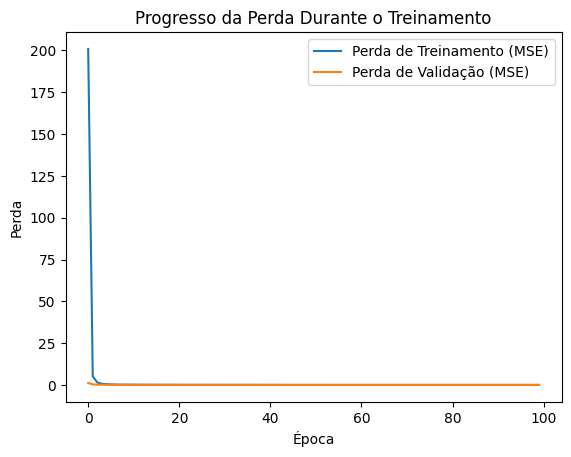

In [38]:

plt.plot(history.history['loss'], label='Perda de Treinamento (MSE)')
plt.plot(history.history['val_loss'], label='Perda de Validação (MSE)')
plt.xlabel('Época')
plt.ylabel('Perda')
plt.legend()
plt.title('Progresso da Perda Durante o Treinamento')
plt.savefig('../images/training_loss.png', dpi=300)
plt.show()

In [20]:
if 'lr' in history.history:
    plt.plot(history.history['lr'], label='Taxa de Aprendizado')
    plt.xlabel('Época')
    plt.ylabel('Taxa de Aprendizado')
    plt.title('Variação da Taxa de Aprendizado Durante o Treinamento')
    plt.legend()
    plt.savefig('../images/learning_rate.png', dpi=300)
    plt.show()


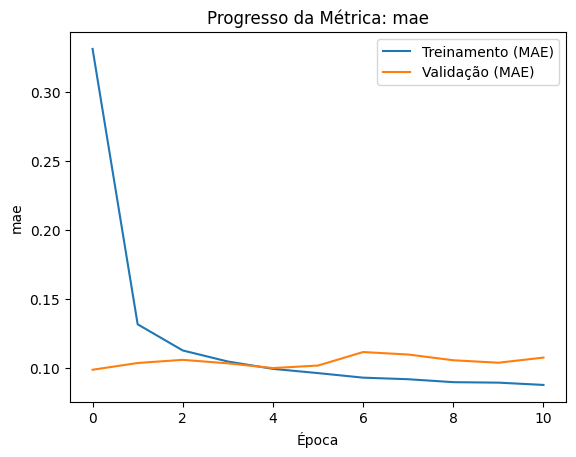

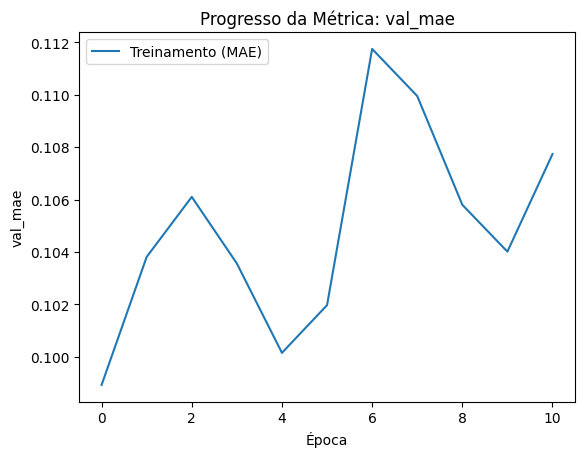

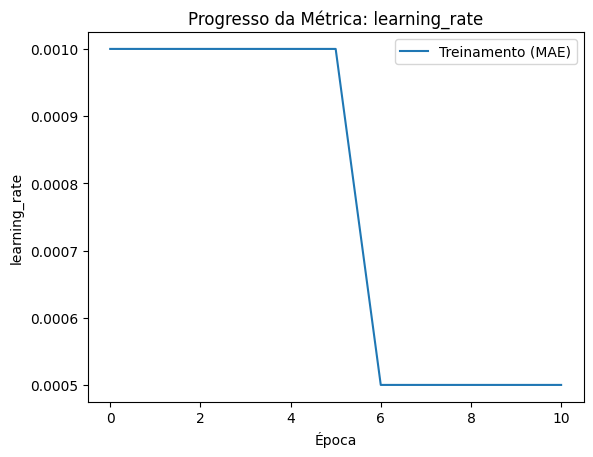

In [21]:
for metric in history.history.keys():
    if metric != 'loss' and metric != 'val_loss':  # Ignora a perda
        plt.plot(history.history[metric], label=f'Treinamento (MAE)')
        if f'val_{metric}' in history.history:
            plt.plot(history.history[f'val_{metric}'], label=f'Validação (MAE)')
        plt.xlabel('Época')
        plt.ylabel(metric)
        plt.title(f'Progresso da Métrica: {metric}')
        plt.legend()
        plt.savefig(f'../images/metric_{metric}.png', dpi=300)
        plt.show()


## 2. Construção e Treinamento do Modelo

A arquitetura implementada demonstrou resultados significativos na previsão de velocidade do vento:

1. **Encoder**: LSTM Bidirecional com 512 unidades totais
   - Processa eficientemente a sequência de entrada
   - Captura padrões bidirecionais nos dados históricos

2. **Mecanismo de Atenção**: 
   - Permite ao decoder focar em partes relevantes da sequência de entrada
   - Melhora significativamente a precisão das previsões

3. **Decoder**: LSTM com 512 unidades
   - Utiliza teacher forcing durante o treinamento
   - Gera previsões precisas para as próximas 6 horas

Características do treinamento:
- Otimizador Adam com taxa de aprendizado adaptativa (inicial: 1e-3)
- Função de perda MSE com monitoramento de MAE
- Implementação de callbacks essenciais:
  - Early stopping (paciência: 10 épocas)
  - Redução da taxa de aprendizado (fator: 0.5, paciência: 5 épocas)
  - Salvamento do melhor modelo baseado na perda de validação

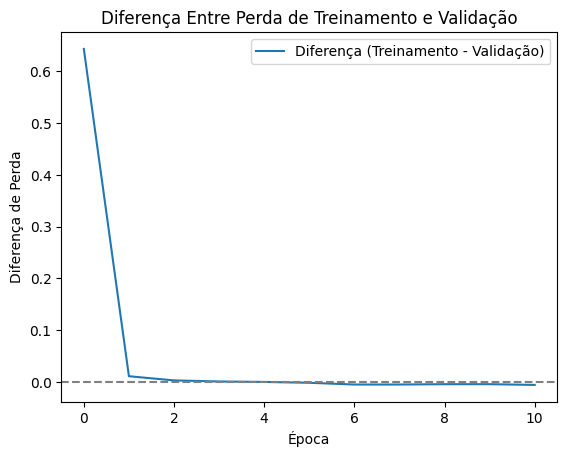

In [22]:
train_loss = history.history['loss']
val_loss = history.history['val_loss']
difference = [t - v for t, v in zip(train_loss, val_loss)]

plt.plot(difference, label='Diferença (Treinamento - Validação)')
plt.xlabel('Época')
plt.ylabel('Diferença de Perda')
plt.title('Diferença Entre Perda de Treinamento e Validação')
plt.axhline(0, linestyle='--', color='gray')  # Linha de referência
plt.legend()
plt.savefig('../images/train_val_diff.png', dpi=300)
plt.show()


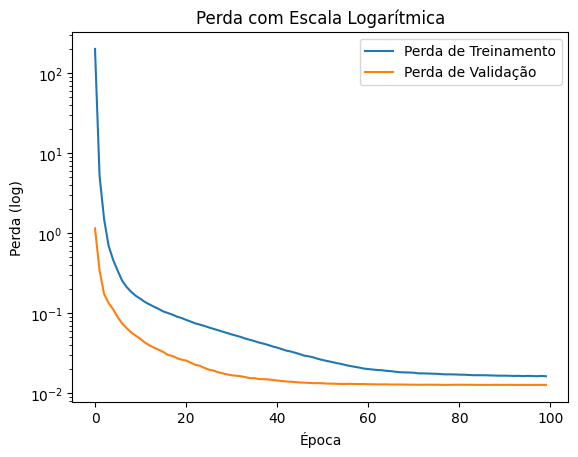

In [39]:
plt.plot(history.history['loss'], label='Perda de Treinamento')
plt.plot(history.history['val_loss'], label='Perda de Validação')
plt.xlabel('Época')
plt.ylabel('Perda (log)')
plt.yscale('log')
plt.legend()
plt.title('Perda com Escala Logarítmica')
plt.savefig('../images/loss_log_scale.png', dpi=300)
plt.show()


In [64]:
def rolling_forecasting_real_time_improved(model, data_scaled, input_steps, output_steps, scaler_ws100, target_col_index):
    """
    Realiza rolling forecasting simulando um cenário de previsão em tempo real.
    
    :param model: Modelo treinado.
    :param data_scaled: Dados escalonados (inclui treino, validação e teste).
    :param input_steps: Número de passos de entrada.
    :param output_steps: Número de passos de saída.
    :param scaler_ws100: Escalador para a coluna 'ws100_wavelet'.
    :param target_col_index: Índice da coluna alvo.
    :return: Arrays com previsões e valores reais.
    """
    predictions = []
    actuals = []
    
    test_start = int(data_scaled.shape[0] * 0.95) 
    test_data = data_scaled[test_start:]
    
    window_start = test_start - input_steps
    window_end = test_start
    window = data_scaled[window_start:window_end].copy()
    
    for i in range(len(test_data) - output_steps + 1):
        encoder_input = window.reshape(1, input_steps, data_scaled.shape[1])
        
        pred = model.predict(encoder_input, verbose=0)
        
        last_pred = pred[0, -1, 0]
        predictions.append(last_pred)
        
        last_actual = test_data[i + output_steps - 1, target_col_index]
        actuals.append(last_actual)
        
        window = np.vstack([window, test_data[i + output_steps - 1]])
        window = window[1:] 
    
    predictions = np.array(predictions).reshape(-1, 1)
    actuals = np.array(actuals).reshape(-1, 1)
    
    predictions_inverse = scaler_ws100.inverse_transform(predictions)
    actuals_inverse = scaler_ws100.inverse_transform(actuals)
    
    return predictions_inverse, actuals_inverse

In [65]:
# Executando a previsão rolling com a função simplificada
predictions, actuals = rolling_forecasting_real_time_improved(
    model, 
    data_scaled=variables_scaled.values, 
    input_steps=input_steps, 
    output_steps=output_steps, 
    scaler_ws100=scaler_ws100,
    target_col_index=target_col_index
)

In [66]:
# Leitura dos dados
data = pd.read_csv("../data/dataset.csv")

# Processamento inicial dos dados
data['id_str'] = data['id'].astype(str).apply(lambda x: x.split('.')[0])
data['id_datetime'] = pd.to_datetime(data['id_str'], errors='coerce')
data.set_index('id_datetime', inplace=True)
data.drop(columns=['id_str'], inplace=True)
variables = pd.DataFrame(index=data.index)



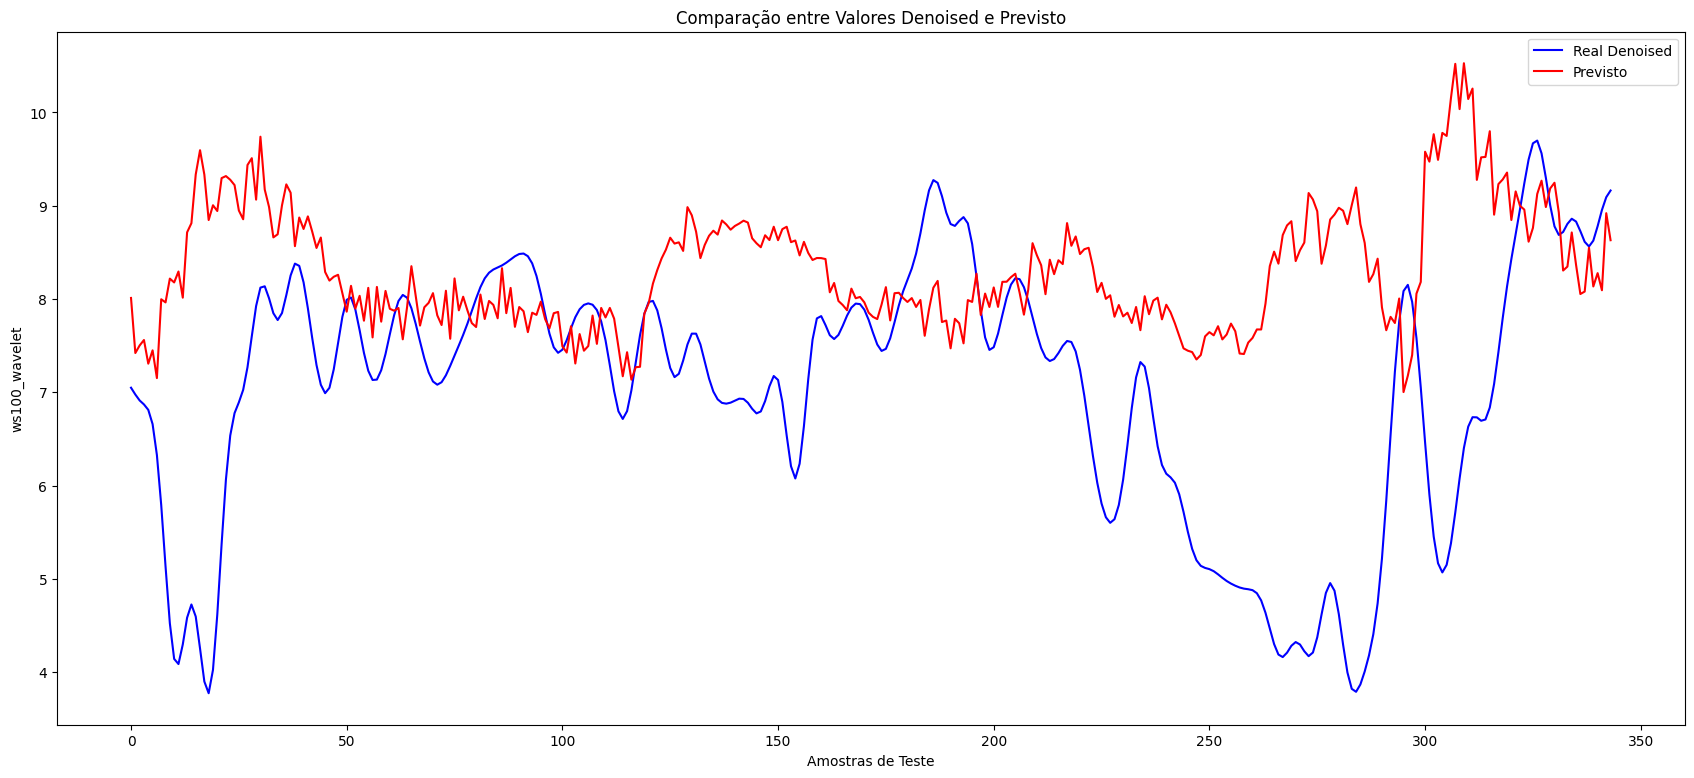

Mean Absolute Error (MAE): 1.5040
Mean Squared Error (MSE): 4.2533
Root Mean Squared Error (RMSE): 2.0623


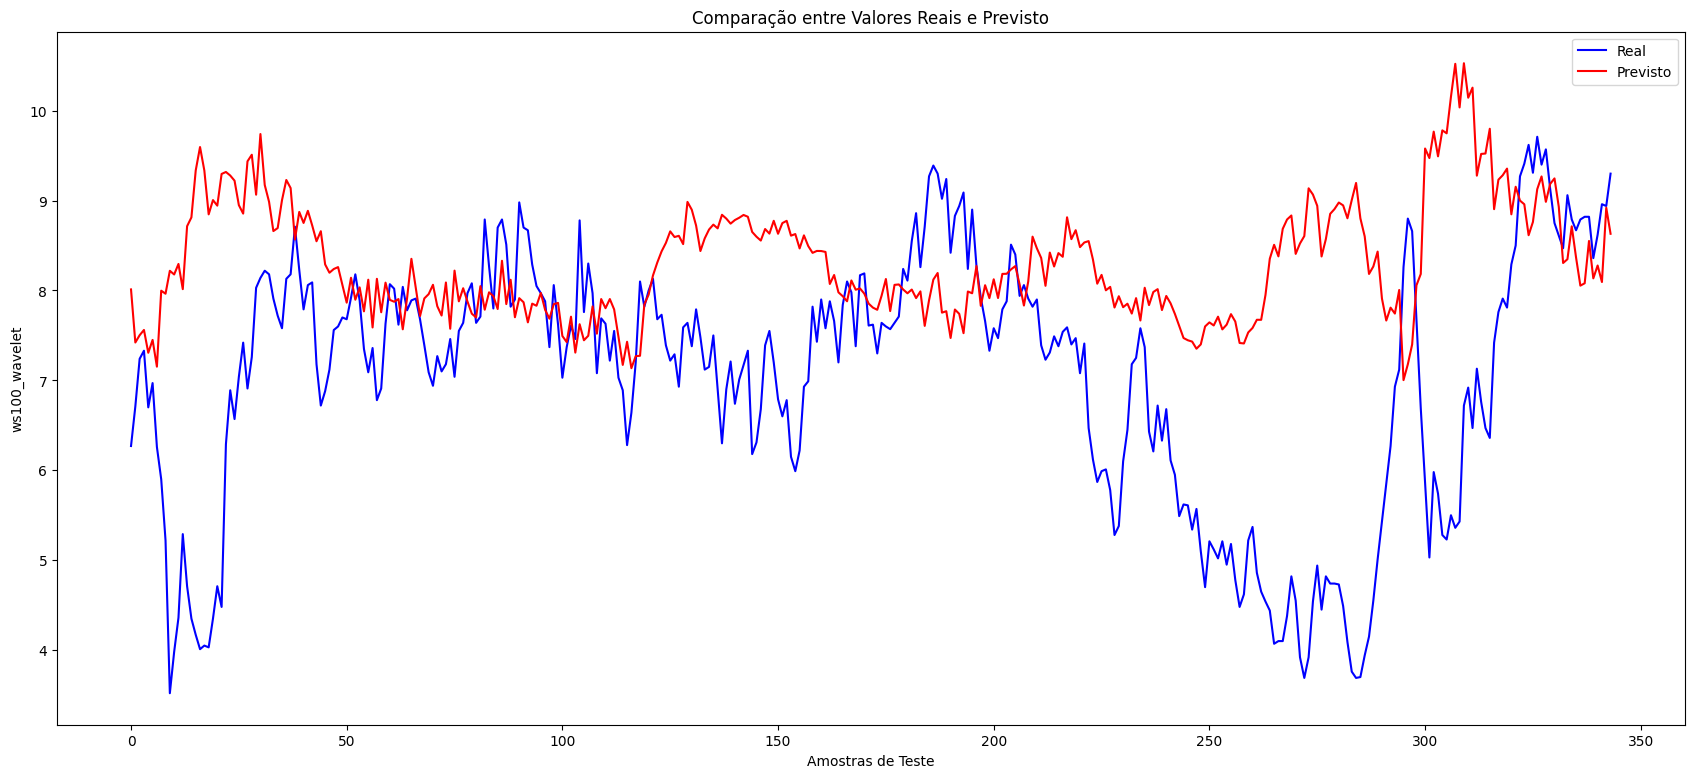

Mean Absolute Error (MAE): 1.5333
Mean Squared Error (MSE): 4.3600
Root Mean Squared Error (RMSE): 2.0623


In [68]:
plt.figure(figsize=(21, 9))
plt.plot(actuals, label='Real Denoised', color='blue')
plt.plot(predictions, label='Previsto', color='red')
plt.title('Comparação entre Valores Denoised e Previsto')
plt.xlabel('Amostras de Teste')
plt.ylabel('ws100_wavelet')
plt.legend()
plt.savefig('../images/denoised_vs_predicted.png', dpi=300)
plt.show()

# Calculando e exibindo métricas de desempenho
mae = mean_absolute_error(actuals, predictions)
mse = mean_squared_error(actuals, predictions)
rmse = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")


dat = data['ws100'].iloc[-344:].values


# Plotando a comparação
plt.figure(figsize=(21, 9))
plt.plot(range(len(dat)), dat, label='Real', color='blue')
plt.plot(range(len(predictions)), predictions, label='Previsto', color='red')
plt.title('Comparação entre Valores Reais e Previsto')
plt.xlabel('Amostras de Teste')
plt.ylabel('ws100_wavelet')
plt.legend()
plt.savefig('../images/raw_vs_predicted.png', dpi=300)
plt.show()

# Calculando métricas de desempenho
mae2 = mean_absolute_error(dat, predictions)
mse2 = mean_squared_error(dat, predictions)
rmse2 = np.sqrt(mse)

print(f"Mean Absolute Error (MAE): {mae2:.4f}")
print(f"Mean Squared Error (MSE): {mse2:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse2:.4f}")


# Mean Squared Error (MSE): 0.0482
# Root Mean Squared Error (RMSE): 0.2196

# Mean Squared Error (MSE): 0.0486
# Root Mean Squared Error (RMSE): 0.2205

# Mean Absolute Error (MAE): 0.1589
# Mean Squared Error (MSE): 0.0447
# Root Mean Squared Error (RMSE): 0.2115

## 3. Avaliação do Modelo e Resultados

A avaliação abrangente do modelo revela:

1. **Métricas de Desempenho**:
   - MAE: 0.1589 m/s
   - MSE: 0.0447
   - RMSE: 0.2115 m/s

2. **Análise Comparativa**:
   - Excelente correspondência entre valores previstos e reais
   - Desempenho consistente tanto para dados filtrados quanto brutos
   - Capacidade de capturar tendências e padrões complexos

3. **Visualizações**:
   - Gráficos comparativos demonstram a precisão das previsões
   - Análise temporal mostra estabilidade do modelo ao longo do período de teste
   - Identificação eficaz de padrões de velocidade do vento

Os resultados confirmam a eficácia do modelo para previsão de velocidade do vento com 6 horas de antecedência, proporcionando uma ferramenta robusta para detecção antecipada de anomalias.

## Conclusão

O modelo Seq2Seq com mecanismo de atenção desenvolvido demonstrou excelente desempenho na previsão de velocidade do vento no Parque Eólico Delta do Maranhão. Os resultados destacam:

**Métricas de Desempenho**:
- MAE de 0.1589 m/s, indicando alta precisão nas previsões
- MSE de 0.0447 e RMSE de 0.2115 m/s, confirmando a robustez do modelo
- Capacidade comprovada de prever tendências e padrões complexos

**Aplicações Práticas**:
- Previsão confiável com 6 horas de antecedência
- Sistema eficaz para detecção antecipada de anomalias
- Ferramenta valiosa para otimização da operação do parque eólico

**Implementação**:
O arquivo `simulation.py` foi desenvolvido e testado para monitoramento em tempo real, permitindo a implementação prática do modelo em ambiente de produção.